In [1]:
import tensorflow as tf
import numpy as np
import cv2
import os
import PIL
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, Sequential

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

In [3]:
data_dir

'.\\datasets\\flower_photos'

In [4]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [5]:
list(data_dir.glob('*/*.jpg'))

[WindowsPath('datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/102841525_bd6628ae3c.jpg'),
 WindowsPath('datasets/flower_photos/daisy/1031799732_e7f4008c03.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10391248763_1d16681106_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10437754174_22ec990b77_m.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10437770546_8bb6f7bdd3_m.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10437929963_bc13eebe0c.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10466290366_cc72e33532.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10466558316_a7198b87e2.jpg'),
 WindowsPath('datasets/flower_photos/daisy/1

In [6]:
image_count = len(list(data_dir.glob('*/*.jpg')))
image_count

3670

In [7]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

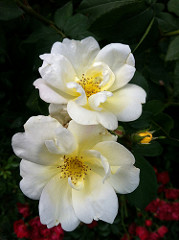

In [8]:
PIL.Image.open(str(roses[0]))

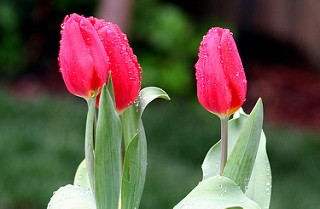

In [9]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [10]:
flowers_image_dict= {
    'roses' : list(data_dir.glob('roses/*')),
    'daisy' : list(data_dir.glob('daisy/*')),
    'dandelion' : list(data_dir.glob('dandelion/*')),
    'sunflowers' : list(data_dir.glob('sunflowers/*')),
    'tulips' : list(data_dir.glob('tulips/*'))
}

In [11]:
flowers_image_dict['dandelion']

[WindowsPath('datasets/flower_photos/dandelion/10043234166_e6dd915111_n.jpg'),
 WindowsPath('datasets/flower_photos/dandelion/10200780773_c6051a7d71_n.jpg'),
 WindowsPath('datasets/flower_photos/dandelion/10294487385_92a0676c7d_m.jpg'),
 WindowsPath('datasets/flower_photos/dandelion/10437652486_aa86c14985.jpg'),
 WindowsPath('datasets/flower_photos/dandelion/10443973_aeb97513fc_m.jpg'),
 WindowsPath('datasets/flower_photos/dandelion/10477378514_9ffbcec4cf_m.jpg'),
 WindowsPath('datasets/flower_photos/dandelion/10486992895_20b344ce2d_n.jpg'),
 WindowsPath('datasets/flower_photos/dandelion/10617162044_8740d4dd9f_n.jpg'),
 WindowsPath('datasets/flower_photos/dandelion/10617191174_9a01753241_n.jpg'),
 WindowsPath('datasets/flower_photos/dandelion/10683189_bd6e371b97.jpg'),
 WindowsPath('datasets/flower_photos/dandelion/1074999133_1e4a1e042e.jpg'),
 WindowsPath('datasets/flower_photos/dandelion/10777398353_5a20bb218c.jpg'),
 WindowsPath('datasets/flower_photos/dandelion/10778387133_9141024b

In [12]:
flowers_labels_dict = {
    'roses' : 0,
    'daisy' : 1,
    'dandelion' : 2,
    'sunflowers' : 3,
    'tulips' : 4
}

In [13]:
img = cv2.imread(flowers_image_dict['roses'][0])
img

array([[[ 0, 15,  6],
        [ 0, 15,  6],
        [ 0, 17,  8],
        ...,
        [24, 51, 31],
        [25, 52, 32],
        [26, 53, 33]],

       [[ 7, 22, 14],
        [ 7, 22, 14],
        [ 6, 21, 13],
        ...,
        [20, 46, 30],
        [23, 49, 33],
        [25, 51, 35]],

       [[12, 23, 15],
        [12, 23, 15],
        [11, 22, 14],
        ...,
        [20, 42, 30],
        [23, 45, 33],
        [26, 48, 36]],

       ...,

       [[19, 30, 27],
        [14, 24, 18],
        [12, 20, 13],
        ...,
        [ 4, 13,  3],
        [ 0,  8,  1],
        [ 0,  5,  0]],

       [[19, 30, 28],
        [18, 27, 24],
        [15, 23, 16],
        ...,
        [ 3, 12,  2],
        [ 1,  9,  2],
        [ 0,  7,  2]],

       [[ 9, 19, 19],
        [17, 25, 24],
        [22, 29, 24],
        ...,
        [ 1, 12,  2],
        [ 2, 10,  3],
        [ 3, 11,  4]]], shape=(240, 179, 3), dtype=uint8)

In [14]:
img.shape

(240, 179, 3)

In [15]:
cv2.resize(img, (180,180)).shape

(180, 180, 3)

In [16]:
X, y = [], []

for flowers_name, images in flowers_image_dict.items():
    for image in images:
        img = cv2.imread(image)
        resized_image = cv2.resize(img, (180,180))
        X.append(resized_image)
        y.append(flowers_labels_dict[flowers_name])

In [17]:
X = np.array(X)
y = np.array(y)

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

In [19]:
len(X_train)

2752

In [20]:
len(X_test)

918

In [21]:
X_train_scaled = X_train /255
X_test_scaled = X_test /255

In [31]:
X_train_scaled[0]

array([[[0.26666667, 0.30980392, 0.30196078],
        [0.24705882, 0.2745098 , 0.24705882],
        [0.23529412, 0.24313725, 0.21960784],
        ...,
        [0.19215686, 0.15686275, 0.14509804],
        [0.18823529, 0.15294118, 0.14117647],
        [0.18823529, 0.15294118, 0.14117647]],

       [[0.22352941, 0.24313725, 0.23529412],
        [0.23921569, 0.25098039, 0.23529412],
        [0.23529412, 0.23921569, 0.21568627],
        ...,
        [0.18823529, 0.15294118, 0.14117647],
        [0.18823529, 0.15294118, 0.14117647],
        [0.19607843, 0.16078431, 0.14901961]],

       [[0.23921569, 0.22745098, 0.22352941],
        [0.25098039, 0.25098039, 0.23137255],
        [0.23137255, 0.23137255, 0.20784314],
        ...,
        [0.19215686, 0.15686275, 0.14509804],
        [0.19215686, 0.15686275, 0.14509804],
        [0.19607843, 0.16078431, 0.14901961]],

       ...,

       [[0.19215686, 0.4745098 , 0.36470588],
        [0.15686275, 0.25490196, 0.2       ],
        [0.20392157, 0

In [28]:
num_classes  = 5

model = Sequential([
    layers.Conv2D(16,3, padding= 'same', activation= 'relu'), 
    layers.MaxPooling2D(),
    layers.Conv2D(32,3, padding= 'same', activation= 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3, padding= 'same', activation= 'relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(num_classes)
])

In [29]:
model.compile(
    optimizer= 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics= ['accuracy']
)

model.fit(X_train_scaled, y_train, epochs= 10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 36s 343ms/step - accuracy: 0.4015 - loss: 1.3579
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 476ms/step - accuracy: 0.5930 - loss: 1.0270
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 489ms/step - accuracy: 0.6606 - loss: 0.8769
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 37s 426ms/step - accuracy: 0.7427 - loss: 0.6877
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 38s 389ms/step - accuracy: 0.8383 - loss: 0.4620
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 39s 355ms/step - accuracy: 0.9023 - loss: 0.2828
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 35s 410ms/step - accuracy: 0.9495 - loss: 0.1683
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 39s 457ms/step - accuracy: 0.9826 - loss: 0.0692
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 35s 408ms/step - accuracy: 0.9924 - loss: 0.0326
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 38s 377ms/step - accuracy: 0.9982 - loss: 0.0152


In [30]:
model.evaluate(X_test_scaled, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.6645 - loss: 1.9605


[1.9604957103729248, 0.6644880175590515]

In [32]:
pred = model.predict(X_test_scaled)
pred

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step


array([[  4.369834  ,  15.972079  ,  -0.13693345, -17.110573  ,
         -7.9646482 ],
       [ 12.759972  ,   4.421063  , -12.157975  ,  -7.886796  ,
          2.5448403 ],
       [ -0.7597042 ,   2.785723  ,  12.182373  , -13.304695  ,
         -0.98022276],
       ...,
       [ -1.3167808 ,  -3.0736318 ,  -9.266397  ,   9.470074  ,
          3.7629728 ],
       [ -0.4852131 ,   3.28656   ,   1.40102   ,   2.4733443 ,
         -4.6535196 ],
       [  1.3072739 , -10.210671  ,   3.033099  ,   7.8723083 ,
          6.4648867 ]], shape=(918, 5), dtype=float32)

In [33]:
score = tf.nn.softmax(pred[0])
score

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([9.1454440e-06, 9.9999070e-01, 1.0091150e-07, 4.2892596e-15,
       4.0216781e-11], dtype=float32)>

In [34]:
np.argmax(score)

np.int64(1)

In [35]:
y_test[0]

np.int64(1)

In [45]:
data_agumentation = keras.Sequential([
    layers.RandomZoom(0.3),
    layers.RandomFlip('horizontal', input_shape = (180, 180, 3)),
    layers.RandomRotation(0.1)
])

C:\Users\Deepak\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


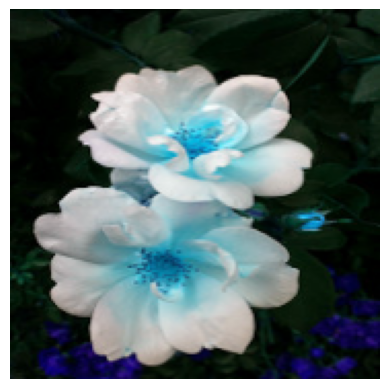

In [46]:
plt.axis('off')
plt.imshow(X[0])

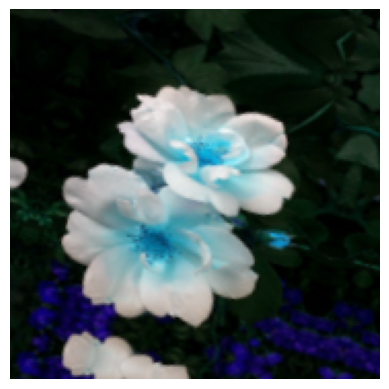

In [47]:
plt.axis('off')
plt.imshow(data_agumentation(X)[0].numpy().astype('uint8'))

In [48]:
num_classes  = 5

model = Sequential([
    data_agumentation,
    layers.Conv2D(16,3, padding= 'same', activation= 'relu'), 
    layers.MaxPooling2D(),
    layers.Conv2D(32,3, padding= 'same', activation= 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3, padding= 'same', activation= 'relu'),
    layers.MaxPooling2D(),

    layers.Dropout(0.2),

    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(num_classes)
])

model.compile(
    optimizer= 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics= ['accuracy']
)

model.fit(X_train_scaled, y_train, epochs= 10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 74s 642ms/step - accuracy: 0.3725 - loss: 1.4108
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 55s 640ms/step - accuracy: 0.5785 - loss: 1.0626
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 55s 633ms/step - accuracy: 0.6337 - loss: 0.9452
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 54s 633ms/step - accuracy: 0.6755 - loss: 0.8596
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 55s 639ms/step - accuracy: 0.6828 - loss: 0.8339
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 55s 635ms/step - accuracy: 0.6879 - loss: 0.8260
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 55s 634ms/step - accuracy: 0.7115 - loss: 0.7628
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 55s 637ms/step - accuracy: 0.7351 - loss: 0.7056
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 51s 593ms/step - accuracy: 0.7336 - loss: 0.6898
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 49s 575ms/step - accuracy: 0.7395 - loss: 0.6720


In [49]:
model.evaluate(X_test_scaled, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.6928 - loss: 0.9293


[0.9293392896652222, 0.6928104758262634]